In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns


In [3]:
base_path = r'D:\Dsoft\Projects\ML\data\road_accidents' + '\\'
sample_submission = base_path + r'sample_submission.csv'
train_path = base_path + r'train.csv'
test_path = base_path + r'test.csv'

In [8]:
df = pd.read_csv(train_path)

In [4]:
def cat_to_num(df):
    cat_cols = ['road_type', \
            'lighting', \
            'weather', \
            'road_signs_present', \
            'public_road', \
            'time_of_day', \
            'holiday', \
            'school_season']
    for i in cat_cols:
        if i not in df.columns:
            print(f"Necessary columns do not exist: {i}")
            raise;
    
    # Boolean columns True:1, False:0
    bool_cols = ['road_signs_present', 'public_road' , 'holiday' , 'school_season']
    for i in bool_cols:
        df[i] = df[i].apply(lambda x: 1 if x else 0)
    
    # road_type ['urban' 'rural' 'highway']
    road_mapping = {'highway': 3, 'urban':2, 'rural': 1}
    df['road_type'] = df['road_type'].map(road_mapping)  

    # lighting ['daylight' 'dim' 'night']
    light_mapping = {'daylight': 1, 'dim':2, 'night': 3}
    df['lighting'] = df['lighting'].map(light_mapping)  

    # weather ['rainy' 'clear' 'foggy']
    weather = {'rainy': 3, 'clear':1, 'foggy': 2}
    df['weather'] = df['weather'].map(weather) 

    # time_of_day ['afternoon' 'evening' 'morning']
    time_of_day = {'afternoon': 2, 'evening':3, 'morning': 1}
    df['time_of_day'] = df['time_of_day'].map(time_of_day) 
    
    return df
    

In [9]:
df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [5]:
cat_cols = ['road_type', \
        'lighting', \
        'weather', \
        'road_signs_present', \
        'public_road', \
        'time_of_day', \
        'holiday', \
        'school_season']

In [12]:
prep_df = cat_to_num(df)

Text(0.5, 1.0, 'Categorical Features Correlation with Accident Severity')

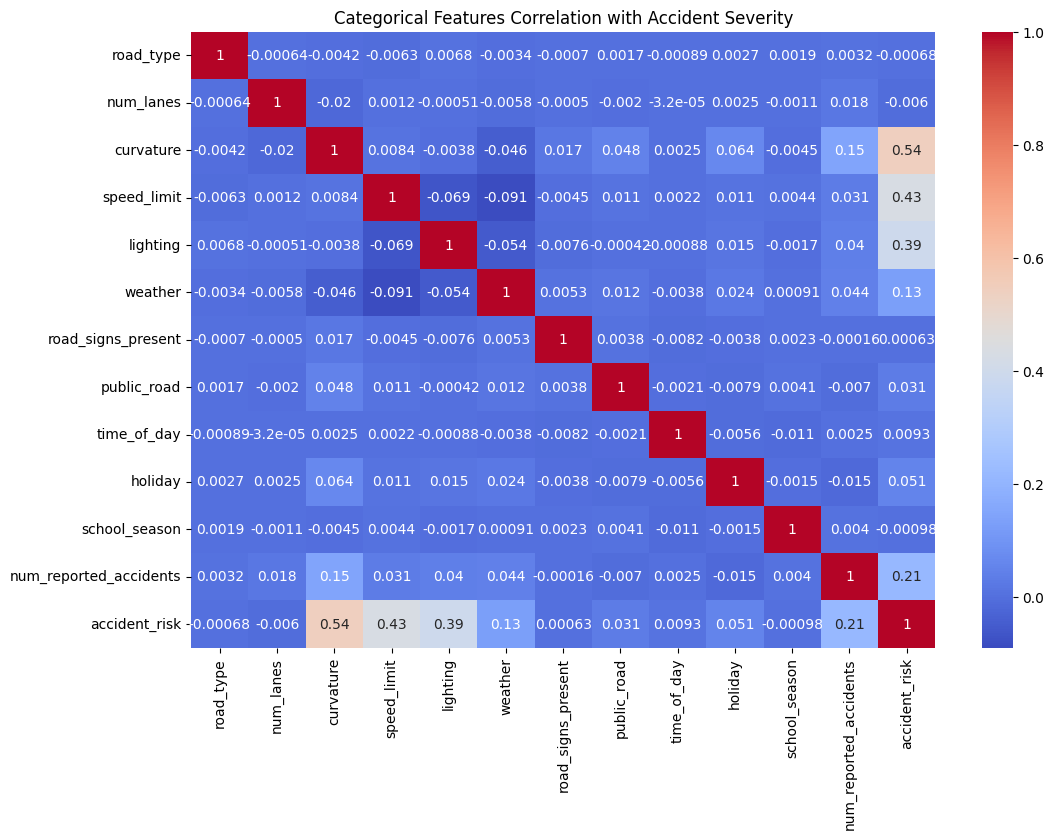

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(prep_df[['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk']].corr(), annot=True, cmap='coolwarm')
plt.title('Categorical Features Correlation with Accident Severity')

In [18]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# columns to scale (keep id and target unchanged)
exclude_cols = ['id', 'accident_risk']
feature_cols = [c for c in prep_df.columns if c not in exclude_cols]

scaler = MinMaxScaler()
prep_norm = prep_df.copy()
prep_norm[feature_cols] = scaler.fit_transform(prep_df[feature_cols])

# quick sanity checks
print("Normalized dataframe shape:", prep_norm.shape)
print(prep_norm[feature_cols].agg(['min', 'max']).T)

# # persist scaler for later use
# joblib.dump(scaler, base_path + 'minmax_scaler.pkl')

Normalized dataframe shape: (517754, 14)
                        min  max
road_type               0.0  1.0
num_lanes               0.0  1.0
curvature               0.0  1.0
speed_limit             0.0  1.0
lighting                0.0  1.0
weather                 0.0  1.0
road_signs_present      0.0  1.0
public_road             0.0  1.0
time_of_day             0.0  1.0
holiday                 0.0  1.0
school_season           0.0  1.0
num_reported_accidents  0.0  1.0


In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(prep_norm[['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk']], annot=True)
plt.title('Features Correlation with Accident Severity')